In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

#filename = "/data/fromlabpix/warm/packet-warm_pedestal-2025_10_28_13_40_41_PDT.h5" # all 5 tiles in B70 cryo. Warm. No channels disabled. Sync pulses
#filename = "/data/fromlabpix/cold/packet-cold_pedestal_5tiles_vdda1p8_nom-2025_10_30_12_16_02_PDT.h5" # Cold. 4 tiles. No channels disabled. Sync pulses
#filename = "../data/packet-warm_5tiles_tally_2025_11_05_12_49_59_PST.h5"
#filename = "../data/packet-warm_4tiles_tally_2025_11_19_09_23_21_PST.h5"

#set1-7 pedestal datafiles after disabling hot channels and links to bit-flipping chips
#filename = "../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_disable-hotchan-link_2026_1_9.hdf5"

# only tile 10 powered up, warm test
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/warm/packet-warm_ped_480s_drops_t10_185vref.hdf5"
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/warm/packet-warm_ped_480s_drops_t10_220vref.hdf5"

# only tile 10 powered up, cold tests
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_1.hdf5"
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_2.hdf5"
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_3.hdf5"
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_ped_150kcycles_480s_t10_drop_pkts_4.hdf5"
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_ped_150kcycles_480s_t10_no_drop.hdf5"

# cold tests of 10tiles taken 2026_02_06 when there was significant noise
#filename = "/data/v3/10x16/20260214_set1_10_tiles/data/cold_12_06/packet-cold_ped_150kcycles_480s_10tiles_1.hdf5"
#filename = "/data/v3/10x16/20260214_set1_10_tiles/data/cold_12_06/packet-cold_ped_150kcycles_480s_10tiles_2.hdf5"
#filename = "/data/v3/10x16/20260214_set1_10_tiles/data/cold_12_06/packet-cold_ped_150kcycles_480s_10tiles_3.hdf5"

# warm tests of set 2 of 10 tiles (tile 4 was replaced with tile 10 from set 1)
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/warm/packet-warm_sync_set2_10tiles_240s_185vref_no_hotchan_1.hdf5"
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/warm/packet-warm_sync_set2_10tiles_240s_185vref_no_hotchan_2.hdf5"

filename =  "/data/v3/10x16/20260312_set2_10_tiles/data/cold/packet-cold_sync_set2_10tiles_240s_220vref_1.hdf5"

#filename =  "/data/v3/10x16/20260505_set3_10_tiles/data/cold/packet-cold_sync_set3_9tiles_240s_220vref_no_hotchan.hdf5"

#filename =  "/data/v3/10x16/20260512_set4_10_tiles/data/cold/packet-cold_sync_set4_10tiles_240s_no_hotchan.hdf5"

# tiles tested in this filename or the subset of tiles to test
#tiles = [1,2,3,4,5,6,7,8,9,10]
#tiles = [1,2,3,4]
tiles = [3]

# serial numbers for set 1 of tiles 1-10
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for sets 2 and 3 
if "set2" in filename:
    setn = 2
    chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]
elif "set3" in filename:
    setn = 3
    chip_serial_number_list = ['', '4k00952', '4k03591', '4k03936', '4k00607', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]
elif "set4" in filename:
    setn = 4
    chip_serial_number_list = ['', '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]    

# use the data filename to determine if this is a cold or warm run
temp = "cold"

if temp not in filename:
    temp = "warm"
    if temp not in filename:
        print(f"The filename did not indicate if this was a cold or warm run")
        
omitted_channels = [56, 57, 58]

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = True

# initialize datafile variables
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
ndisabled_channels = [0 for chp in range(256)]
all_tile_incremental_diff = []
all_tile_max_differences = []
network = {}
debug_count, ntiles, bad_channels = 0, 0, []
first_tile = True
n_bad_dt = [[[0 for chn in range(64)] for chp in range(171)] for tile in range(11)]
npkts_chan = [[[0 for chn in range(64)] for chp in range(171)] for tile in range(11)]
n_chips_0_pkts = 0
n_pkts_total, n_chips_total = 0, 0
large_extra_ticks = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
# count the number of syncs received by each chip

def count_syncs(ts, receipt_ts):

    global list_n_syncs
    
    # initialize variables
    n_syncs = 0
    
    list_receipt_ts = receipt_ts.tolist()
    list_ts = ts.tolist()
    

    # check each value to see if it is the max of a peak
    for i in range(len(list_ts)-1):        
        
        # this qualification signals a peak timestamp was found
        if list_ts[i+1] < list_ts[i]: 
            n_syncs += 1
    
    list_n_syncs.append(n_syncs)
        
    return
   

In [4]:
def check_syncs(ioch, tile, chip, ts, receipt_ts, base, chans):

    global missing_sync_chip_count, sync_chips, max_10, debug_count, all_tile_incremental_diff
    global chip_serial_number, consecutive_missing_syncs, nsyncs, all_tile_max_differences, temp
    global percent_missing_list, verbose, bad_chans, n_bad_dt, ntiles, bad_channels, npkts_chan
    global n_pkts_total, setn, n_chips_0_pkts, n_chips_total, large_extra_ticks

    # initialize variables
    missing, sync_received = 0, 0
    high_time = False
    diff_ts = []
    incremental_diff, i_dt, dt, channels = [] , [], [], []  
    bad_chip = False
    max_clock_ts = 134217727 
    
    list_receipt_ts = receipt_ts.tolist()
    list_ts = ts.tolist()

    max_ts = max(list_ts)

    n_pkts_total += len(list_ts)
    n_chips_total += 1

    # when determining the difference between the 2 timestamps the absolute value will account for cases
    # where the receipt timestamp reset while the packet timestamp was already on its way to the pacman
    # i.e. the packet timestamp would be larger than the receipt ts. This would give a value that is close to
    # but not above 1E7
    for i in range(1,len(list_ts)):
            
        diff_ts.append(abs(list_receipt_ts[i] - list_ts[i]))

        # also get dt without the absolute value
        dt.append(list_receipt_ts[i] - list_ts[i])
        channels.append(chans[i])
    
    # there should be a reasonably consistent difference between Receipt Timestamps and packet timestamps,
    # which accounts for the time to travel from chip to pacman. Δt greater than that amount indicates 
    # either missing syncs, slowly rising chip sync pulses, or the receipt timestamp
    # reset while the packet was traveling to the pacman. Subtract that consistent difference from Δt

    if len(diff_ts) > 0:
        min_dt = min(diff_ts) 
    else:
        print(f"Set-Tile-Chip {setn}-{tile}-{chip}: No pkts after excluding duplicate or invalid packets")
        n_chips_0_pkts +=1
        return
    
    for i in range(len(diff_ts)):
        
        incremental_diff.append(diff_ts[i] - min_dt)
        i_dt.append(dt[i] - min_dt)

        # count the number of times a given channel had more than 1000 extra ticks (but didn't miss a sync)
        if (dt[i] - min_dt) > 1000 and (dt[i] - min_dt) < 1E7: 
            n_bad_dt[tile][chip][channels[i]] +=1
            bad_channels.append(channels[i])
            large_extra_ticks.append(dt[i] - min_dt)
            bad_chip = True
    
    # store values for graphing
    max_differences.append(max(incremental_diff))
    sync_chips.append(chip)
    
    # a max_ts > 1E7 +1E5 most likely flags that a sync has been missed. The last packet might have had
    # extra ticks because the next sync pulse may have been slow-rising (i.e. triggered later
    # than is typical)
    if max_ts > 1E7 + 1E5:

        #fig, ax = plt.subplots(figsize=(10, 3))
        #ax.plot(list_ts)
        #ax.set_xlim(0,100)        
        #ax.set_title(f'Tile {tile} Chip {chip} Timestamps\n{temp} test v3a Tile #{chip_serial_number}')
        #ax.set_xlabel(f'Packets')
        #ax.set_ylabel(f'Timestamp')

        #local_max = max(list_ts[0:1000])
        #print(f"Max value in 1st 1000 packets = {local_max}")
        
        missing_sync_chip_count +=1
    
        # syncs arrive every second (i.e. 1E7). The "int" rounds the fraction down, so if a sync was not 
        # missed this value would be zero instead of 1
        consecutive_missing_syncs.append(int(max_ts/1E7))

        # the clock resets after clock ticks reach a max value of 134,217,727. When determining the 
        # number of consecutive missing syncs this feature must be accounted for
        cumulative_ts_list = []
        n13_peaks, n_sync_peaks = 0, 0
        missing_sync_count_list, episode_list = [], []

        # check each value to see if it is the max of a peak
        for i in range(len(list_ts)-1):

            # accumulate timestamps. if the previous peak was near the clock reset, then add the number
            # of such peaks x 1E7 to the value of the subsequent timestamps 
            cumulative_ts_list.append(n13_peaks * max_clock_ts + list_ts[i])
                
            # this qualification signals a peak timestamp was found
            if list_ts[i+1] < list_ts[i]: 
                
                # if the peak timestamp is near the clock reset value a sync was not received so increment
                # the multiplier for the next round of timestamps and keep counting
                if list_ts[i] > 13E7: 
                    n13_peaks +=1
                    
                # if the peak value is not near the clock reset value then a new sync was received. This 
                # ends one consecutive missing sync "episode"
                else:
                        
                    # count the number of successful syncs
                    n_sync_peaks += 1
                    
                    # create a list (for graphing) of how many syncs were missed in each episode
                    missing_sync_count_list.append(int(max(cumulative_ts_list)/1E7))
                    episode_list.append(len(missing_sync_count_list))
                        
                    # reset the "episode" counters
                    cumulative_ts_list = []
                    n13_peaks = 0
        
        # look for fringe cases where the last episode was not recorded because no non-clock reset peak was found
        if n13_peaks > 0:
            missing_sync_count_list.append(int(max(cumulative_ts_list)/1E7))
            episode_list.append(len(missing_sync_count_list))
                        
        debug_count +=1
            
        try:
            consecutive_missing_syncs[-1] = max(missing_sync_count_list)
        except:
            print(f"Chip {chip} problem: missing_sync_count_list = {missing_sync_count_list}")

        #percent_missing_syncs = 100*consecutive_missing_syncs[-1]/nsyncs
        percent_missing_syncs = 100 * (1 - n_sync_peaks / nsyncs)
        percent_missing_list.append(percent_missing_syncs)

        if percent_missing_syncs > 1:
            print(f"Chip {tile}-{chip} missed {percent_missing_syncs:.1f}% of syncs")

            fig, axis = plt.subplots(1,2, figsize=(10, 3))
            axis[0].plot(list_ts)
            axis[0].set_title(f'Tile {tile} Chip {chip} Timestamps\n{temp} test v3a Tile #{chip_serial_number}')
            axis[0].set_xlabel(f'Packets')
            axis[0].set_ylabel(f'Timestamp')
            
            axis[1].bar(episode_list, missing_sync_count_list)
            axis[1].set_title(f'Tile {tile} Chip {chip}: Consecutive Missing Sync Episodes\n{temp} test v3a Tile #{chip_serial_number}')
            axis[1].set_xlabel(f'Episode of Missing Syncs')
            axis[1].set_ylabel(f'Count of Consecutive Missing Syncs')
            plt.tight_layout()
            plt.show    

    else:
        consecutive_missing_syncs.append(0)
        percent_missing_list.append(0)
        #if max_differences[-1] > 1000 and max_differences[-1] < 1E4:
        #    bad_chip = True
        
    all_tile_incremental_diff.extend(incremental_diff)
    all_tile_max_differences.append(max(incremental_diff)) 

    # bad chips are those with extra-ticks in the O(1E3) range. If one is found the xlim in the last 2 graphs
    # will need to be adjusted to isolate one large extra-tick case
    if bad_chip:
        print(f"Tile {tile} Chip {chip} had extra-ticks in bin[1000, 1E7]")

        fig, axis = plt.subplots(1,2, figsize=(10, 3))
        axis[0].plot(list_ts, color = 'm')
        axis[0].set_title(f'Setn {setn} Tile {tile} Chip {chip} Timestamps\n{temp} test v3a Tile #{chip_serial_number}')
        axis[0].set_xlabel(f'Packets')
        axis[0].set_ylabel(f'Timestamp')
            
        axis[1].plot(i_dt, color = 'm')
        axis[1].set_title(f'Setn {setn} Tile {tile} Chip {chip}: Extra Ticks (some in range[1E3,1E7])\n{temp} test v3a Tile #{chip_serial_number}')
        axis[1].set_xlabel(f'Packets')
        axis[1].set_ylabel(f'Extra Ticks')
        plt.tight_layout()
        plt.show    

        fig, axis = plt.subplots(1,2, figsize=(10, 3))
        axis[0].plot(list_ts, color = 'm')
        axis[0].set_xlim(5200,5300)
        axis[0].set_title(f'Setn {setn} Tile {tile} Chip {chip} Zoom into Timestamps\n{temp} test v3a Tile #{chip_serial_number}')
        axis[0].set_xlabel(f'Packets')
        axis[0].set_ylabel(f'Timestamp')
            
        axis[1].plot(i_dt, color = 'm')
        axis[1].set_title(f'Setn {setn} Tile {tile} Chip {chip}: Zoom into Extra Ticks (some in range[1E3,1E7])\n{temp} test v3a Tile #{chip_serial_number}')
        axis[1].set_xlabel(f'Packets')
        axis[1].set_xlim(5200,5300)
        axis[1].set_ylabel(f'Extra Ticks')
        plt.tight_layout()
        plt.show    
    
    return
   

In [5]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_chan, ndisabled_channels, missing_sync_chip_count, consecutive_missing_syncs
    global chip_serial_number, max_differences, first_tile, nsyncs, list_n_syncs, percent_missing_list, ntiles
    
    # initialize tile variables
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    invalid_chips, ninvalid, ninvalid_by_chip = [], 0, []
    full_chips   , nfull   , nfull_by_chip    = [], 0, []
    bad_std, bad_mean = 0, 0
    bad_std_list, bad_mean_list = [], []
    mean_adc_list, std_adc_list = [], []
    unique_chips  = []
    percent_missing_list = []
    nsyncs = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    list_n_syncs = []
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # get the list of active chips    
    unique_chips = list(dict.fromkeys(packets['chip_id'][:]))    

    # mask for sync packets (type 6)
    sync_mask = packets['packet_type'] == 6
    nsyncs_tile = len(packets[sync_mask])  
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # exclude packets with invalid parity
    valid_mask  = data_pkts['valid_parity'] == 1
    data_pkts  = data_pkts[valid_mask]    
    
    if first_tile:
        print(f"\t{nsyncs_tile} externally generated syncs were collected for a data file of {livetime}s")
        print(f"\tIO_channels in file: \n\t{[int(x) for x in unique_io_channels]}")
        first_tile = False

    print(f'\n############ Checking Syncs for Tile {tile}')
    
    # mask for the chosen tile
    io_channel_ids = get_io_channels(tile)
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    npkts = len(data_pkts) 

    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return

    ntiles +=1
    
    # correct the timestamps and remove duplicate or invalid packets
    base = 134217728
    for i in range(len(data_pkts)):

        # the most significant bit from the 28-bit timestamp was sometimes used for other purposes, so we need to
        # check to see if the timestamp is larger than (10)^27 in binary notation, or 134,217,728 in decimal notation
        # If so subtract that value from the timestamp
        if data_pkts[i]['timestamp'] > base:
            data_pkts[i]['timestamp'] = data_pkts[i]['timestamp'] - base

        # remove duplicate packets
        if i ==0:
            continue
        elif data_pkts[i]['timestamp'] == data_pkts[i-1]['timestamp']:
            data_pkts.remove(data_pkts[i])

        # remove misnumbered chips (which indicate bit flips before parity is assigned)
        if data_pkts[i]['chip_id'] < 11 or data_pkts[i]['chip_id'] > 171:
            data_pkts.remove(data_pkts[i])            
        
    # graph timestamps to look for a tail that suggests missing syncs at the tile level
    fig, axis = plt.subplots(1, 2, figsize=(14, 3))
    axis[0].hist(data_pkts[:]['timestamp'], bins = 100, color='g')
    axis[0].set_title(f'Tile {tile} Timestamps After MSB Mask\n{temp} test of v3a Tile #{chip_serial_number}')
    axis[0].set_xlabel(f'Timestamp')
    axis[0].set_yscale(f'log')
    plt.axvline(x=1E7, color='r', linestyle='--')
    axis[0].set_ylabel(f'Count in Bin')

    # graph receipt timestamps to look for a tail suggesting missing syncs at the pacman level
    axis[1].hist(data_pkts[:]['receipt_timestamp'], bins = 100, color='g')
    axis[1].set_title(f'Tile {tile} Receipt Timestamps\n{temp} test of v3a Tile #{chip_serial_number}')
    axis[1].set_xlabel(f'Receipt Timestamp')
    axis[1].set_yscale(f'log')
    plt.axvline(x=1E7, color='r', linestyle='--')
    plt.show 
    
#########################################################
# identify missing syncs
##########################################################
    
    data_chips = data_pkts['chip_id'][:]

    unique_chips = list(dict.fromkeys(data_chips))

    # count the # of syncs receieved by each chip
    for chip in unique_chips:

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel']
        chip_ts    = chip_pkts['timestamp'][:]
        chip_receipt_ts = chip_pkts['receipt_timestamp'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))

        count_syncs(chip_ts, chip_receipt_ts)

    # determine the expected # of syncs
    nsyncs = mode(list_n_syncs)
    print(f"\nThe most common # of syncs received by a chip = {nsyncs}\n")
    
    # check for missing syncs and count extra-ticks
    for chip in unique_chips:
        
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel']
        chip_chans = chip_pkts['channel_id'][:]
        chip_ts    = chip_pkts['timestamp'][:]
        chip_receipt_ts = chip_pkts['receipt_timestamp'][:]
        
        # count missing syncs (for all but disabled chips)
        if len(chip_ts) > 0:
            check_syncs(chip_ioch, tile, chip, chip_ts, chip_receipt_ts, base, chip_chans)

        # count the typical # of pkts in each channel
        for chan in range(64):
            npkts_chan[tile][chip][chan] = np.count_nonzero(chip_chans == chan)

    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.bar(sync_chips, consecutive_missing_syncs)
    ax.set_title(f'Tile {tile} Max # of Consecutive Missing Syncs per Chip\n {missing_sync_chip_count} chips w missing syncs\n{temp} test of v3a Tile #{chip_serial_number}')
    ax.set_xlabel(f'Chip ID')
    ax.set_ylabel(f'Missing Sync Count')

    if len(sync_chips) != len(percent_missing_list):
        print(f"Problem: len(sync_chips) != len(percent_missing_list)\n\tsync_chips {sync_chips}\n\tpercent_missing_list {percent_missing_list}")
    
    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.bar(sync_chips, percent_missing_list)
    ax.set_title(f'Tile {tile} % of Missing Syncs by Chip\n {missing_sync_chip_count} chips w missing syncs\n{temp} test of v3a Tile #{chip_serial_number}')
    ax.set_xlabel(f'Chip ID')
    ax.set_ylabel(f'Percent of Missing Syncs')
    
    bins = [0,4, 50, 100, 1E4, 1E7]
    tick_labels = [ "4","50","100","1E4","1E7" ]
    hist, bin_edges = np.histogram(max_differences, bins) # make the histogram
    
    fig, axis = plt.subplots(1,2, figsize=(12, 3))
    axis[0].bar(range(len(hist)),hist,width=1) 
    axis[0].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[0].set_xticklabels(tick_labels)
    axis[0].set_title(f'Tile {tile} Chip Count in Max-Extra-Tick Bins\nNot shown are chips w missing syncs\n{temp} test of v3a Tile #{chip_serial_number}')
    axis[0].set_yscale('log')
    axis[0].set_xlabel('Maximum # of Extra Ticks (by Chip)')
    axis[0].set_ylabel(f'# of Chips')
    
    axis[1].bar(sync_chips, max_differences)
    axis[1].set_title(f'Tile {tile} Maximum Extra Ticks by Chip\n{missing_sync_chip_count} missing syncs\n{temp} test of v3a Tile #{chip_serial_number}')
    axis[1].set_xlabel(f'Chip ID')
    axis[1].set_yscale('log')
    axis[1].set_ylabel(f'Max Incremental Δt')         
    plt.show 
   
    print(f'\n{missing_sync_chip_count} chips have missing syncs\n')
        
    
    return 

In [6]:
##########################################################################
# histogram extra ticks for all of the tiles initialized in this script
##########################################################################

def graph_all_tile(dt, max_dt):

    global tiles, n_pkts_total, n_chips_0_pkts, n_chips_total

    print(f'\n################### {len(tiles)} Tile Summary')
    
    bins = [0,4, 50, 100, 1E4, 1E7]
    tick_labels   = [     "4","50","100","1E4","1E7" ]
    tick_labels_0 = [ "0","4","50","100","1E4","1E7" ]

    # get "extra tick" percentages by bin for all packets in all tiles
    counts, bins = np.histogram(dt, bins)
    total = counts.sum()
    percentages = 100 * counts / total

    print(f'\n% of Extra Ticks by Packet for all {len(tiles)} tiles tested:')
    for i in range(len(bins)-1):
        print(f'\t Bin {tick_labels_0[i]}-{tick_labels_0[i+1]}:\t {percentages[i]:.2f}%\t {counts[i]} pkts')
    
    # repeat the procedures above for the maximum extra tick count per chip for all tiles
    counts, bins = np.histogram(max_dt, bins)
    total = counts.sum()
    percentages = counts / total * 100

    print(f'\n% of Maximum Extra Ticks by Chip for all {len(tiles)} tiles tested:')
    for i in range(len(bins)-1):
        print(f'\t Bin {tick_labels_0[i]}-{tick_labels_0[i+1]}:\t {percentages[i]:.2f}%\t {counts[i]} chips')
    
    print(f"\n{100*n_chips_0_pkts/n_chips_total:.2f}% of chips had 0 pkts after excluding duplicates and invalids")    
    
    # histogram "extra tick" counts for all packets
    hist, bin_edges = np.histogram(dt, bins)
    
    fig, axis = plt.subplots(1,2, figsize=(12, 3))

    axis[0].bar(range(len(hist)),hist,width=1) 
    axis[0].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[0].set_xticklabels(tick_labels)
    axis[0].set_title(f'{len(tiles)} Tiles: Extra-Ticks\nNot shown are chips w missing syncs\n{temp} test of v3a')
    axis[0].set_yscale('log')
    axis[0].set_xlabel('Extra Ticks')
    axis[0].set_ylabel(f'# of Packets')
    
    # histogram maximum "extra tick" counts for all chips
    hist, bin_edges = np.histogram(max_dt, bins) # make the histogram
    
    axis[1].bar(range(len(hist)),hist,width=1) 
    axis[1].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[1].set_xticklabels(tick_labels)
    axis[1].set_title(f'{len(tiles)} Tiles: Max Extra-Ticks by Chip \nNot shown are chips w missing syncs\nBenchtop test of v3a')
    axis[1].set_yscale('log')
    axis[1].set_xlabel('Extra Ticks')
    axis[1].set_ylabel(f'# of Chips')
    plt.show     

    fig, axis = plt.subplots(1,2, figsize=(12, 3))

    axis[0].hist(dt) 
    axis[0].set_title(f'{len(tiles)} Tiles: Extra-Ticks\nNot shown are chips w missing syncs\n{temp} test of v3a')
    axis[0].set_yscale('log')
    axis[0].set_xlabel('Extra Ticks')
    axis[0].set_ylabel(f'# of Packets')
    
    axis[1].hist(max_dt) 
    axis[1].set_title(f'{len(tiles)} Tiles: Max Extra-Ticks by Chip \nNot shown are chips w missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[1].set_yscale('log')
    axis[1].set_xlabel('Extra Ticks')
    axis[1].set_ylabel(f'# of Chips')
    plt.show     
    
    return


In [7]:
'''
create a file for extra ticks
'''

def write_dt_to_file(dt, max_dt, bad_channels, nbad_list, percent_bad_chan):   

    global temp, setn
    
    filename = f'../data/extra_ticks_{temp}_set_{setn}.hdf5'
    
    with h5py.File(filename, 'w') as f:
            
        f.create_dataset('dt', data = dt, dtype=int)
        f.create_dataset('max_dt', data = max_dt, dtype=int)  
        f.create_dataset('bad_channels', data = bad_channels, dtype=int) 
        f.create_dataset('nbad_list', data = nbad_list, dtype=int)
        f.create_dataset('percent_bad_chan', data = percent_bad_chan, dtype=int)
        
        f.close()  

    print(f"\nExtra tick file written to {filename}\n")
    
    return

In [8]:
def graph_n_bad_by_channel(n_bad, bad_channels):

    global ntiles, nbad_list, omitted_channels, percent_bad_chan, large_extra_ticks

    nbad_list, percent_bad_chan, npkts_list = [], [], []
    nchans = 0

    # create a list of the # of times a given channel has > 1000 extra ticks (or missed syncs)
    for tile in tiles:
        for chip in range(171):
            for chan in range(64):
                if chan in omitted_channels:
                    continue
                nchans +=1
                if n_bad[tile][chip][chan] > 0:
                    nbad_list.append(n_bad_dt[tile][chip][chan])
                    npkts_list.append(npkts_chan[tile][chip][chan])
                    percent_bad_chan.append(100*n_bad[tile][chip][chan]/npkts_chan[tile][chip][chan])
                    
    mode_npkts = mode(npkts_list)
    print(f"\nThe most common # of packets by channel = {mode_npkts}")
    
    nbad_channels = len(nbad_list)
    percent_bad = 100 * nbad_channels / nchans
    
    print(f"\n{nbad_channels} channels ({percent_bad:.1f}% of channels tested) experienced Extra Clock Ticks > 1000")
    
    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.hist(nbad_list, bins = max(nbad_list))
    ax.set_title(f'# of Instances of 1000 < Extra Ticks < 1E7 by Channel\nExpected # pkts per channel = {mode_npkts}\n{percent_bad:.1f}% of Channels, {temp} test, Set {setn} of {ntiles} v3a Tiles')
    ax.set_xlabel(f'# of Instances of 1000 < Extra Ticks < 1E7')
    ax.set_ylabel(f'# of Channels')
    ax.set_yscale("log")
    plt.show

    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.hist(bad_channels, bins = max(bad_channels))
    ax.set_title(f'Channels with 1000 < Extra Ticks < 1E7\n{percent_bad:.1f}% of Channels, {temp} test, Set {setn} of {ntiles} v3a Tiles')
    ax.set_xlabel(f'Channel ID')
    ax.set_ylabel(f'# of Channels')
    ax.set_yscale("log")
    plt.show

    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.hist(large_extra_ticks, bins = 100)
    ax.set_title(f'1000 < Extra Ticks < 1E7\n{temp} test, Set {setn} of {ntiles} v3a Tiles')
    ax.set_xlabel(f'Extra Ticks')
    ax.set_ylabel(f'# of Packets')
    ax.set_yscale("log")
    plt.show
    
    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.hist(percent_bad_chan, bins = 100)
    ax.set_title(f'% of Each Channels pkts with 1000 < Extra Ticks < 1E7\n{percent_bad:.1f}% of Channels, {temp} test, Set {setn} of {ntiles} v3a Tiles')
    ax.set_xlabel(f'% of Each Channels Packets')
    ax.set_ylabel(f'# of Channels')
    ax.set_yscale("log")
    plt.show    

    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.hist(npkts_list, bins = max(npkts_list))
    ax.set_title(f'# of Packet in each Channel\n{temp} test, Set {setn} of {ntiles} v3a Tiles')
    ax.set_xlabel(f'# of Pkts')
    ax.axvline(x = mode_npkts, color='r', linestyle='--')    
    ax.set_ylabel(f'# of Channels')
    ax.set_yscale("log")
    plt.show    
    
    return
        


Run Statistics:
	263 externally generated syncs were collected for a data file of 240s
	IO_channels in file: 
	[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23, 25, 26, 27, 29, 30, 31, 33, 34, 35, 37, 38, 39]

############ Checking Syncs for Tile 3

The most common # of syncs received by a chip = 239

Tile 3 Chip 138 had extra-ticks in bin[1000, 1E7]
Tile 3 Chip 91 had extra-ticks in bin[1000, 1E7]
Chip 3-68 missed 97.9% of syncs
Tile 3 Chip 68 had extra-ticks in bin[1000, 1E7]
Chip 3-127 missed 59.0% of syncs
Chip 3-86 missed 100.0% of syncs
Tile 3 Chip 86 had extra-ticks in bin[1000, 1E7]

3 chips have missing syncs


################### 1 Tile Summary

% of Extra Ticks by Packet for all 1 tiles tested:
	 Bin 0-4:	 98.39%	 2479705 pkts
	 Bin 4-50:	 0.83%	 20818 pkts
	 Bin 50-100:	 0.63%	 16002 pkts
	 Bin 100-1E4:	 0.00%	 13 pkts
	 Bin 1E4-1E7:	 0.15%	 3844 pkts

% of Maximum Extra Ticks by Chip for all 1 tiles tested:
	 Bin 0-4:	 9.46%	 7 chips
	 Bin 4-50:	 85.1

/tmp/ipykernel_1152348/3984113276.py:52: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 3))


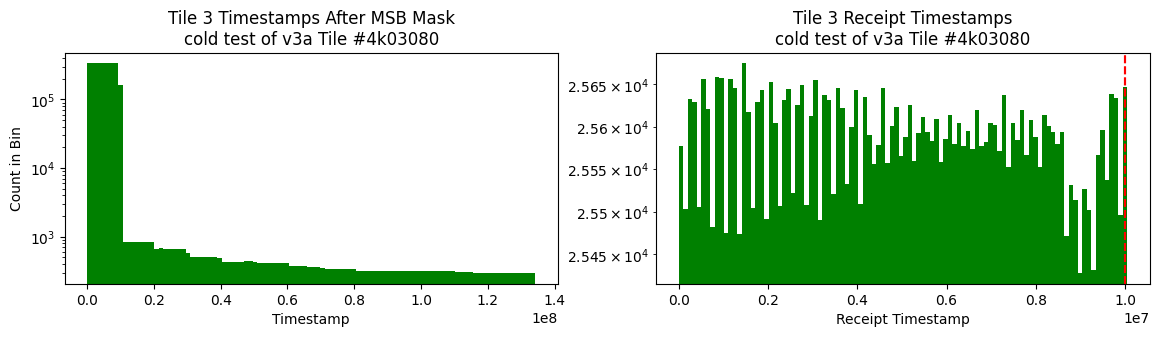

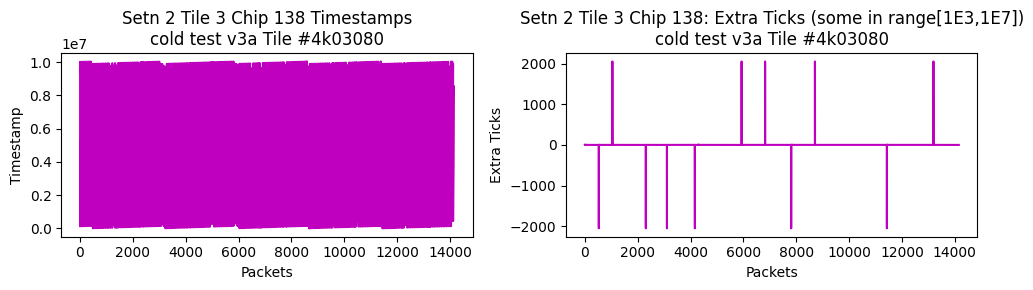

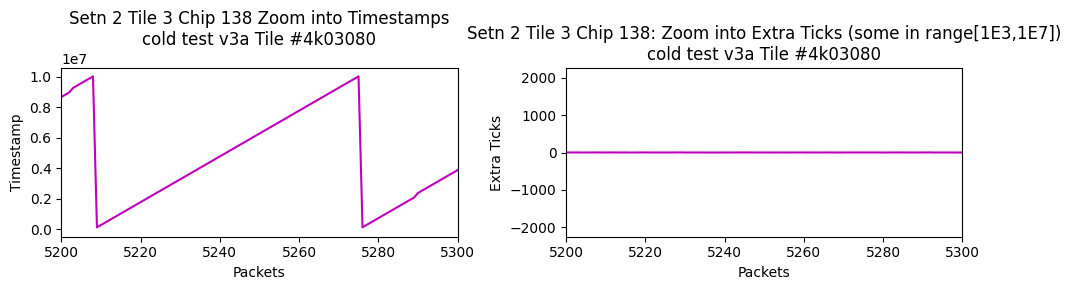

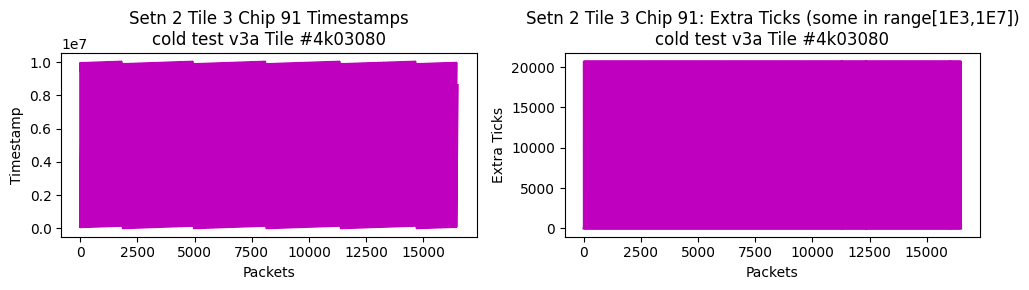

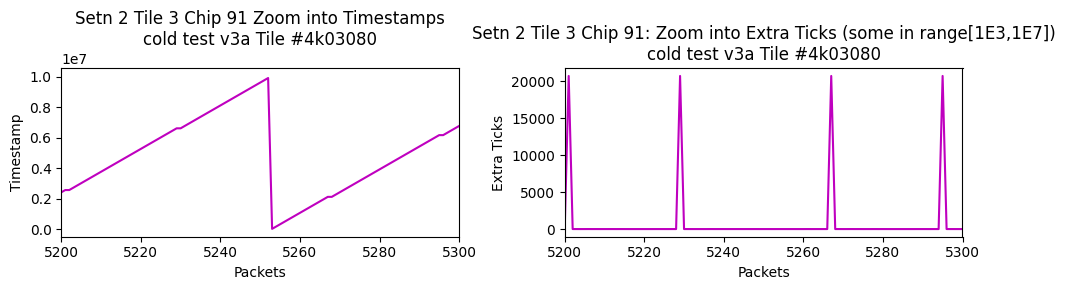

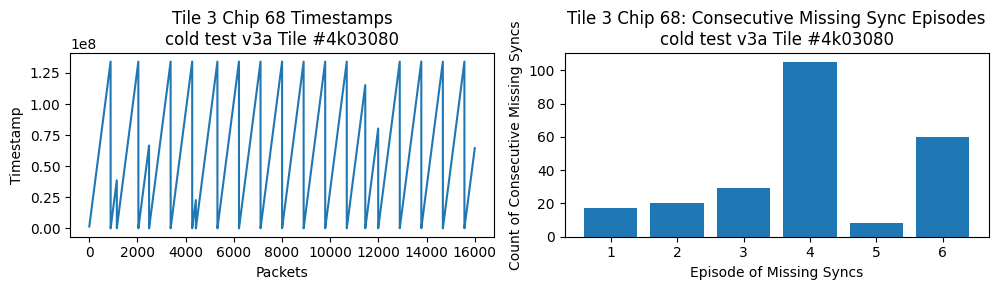

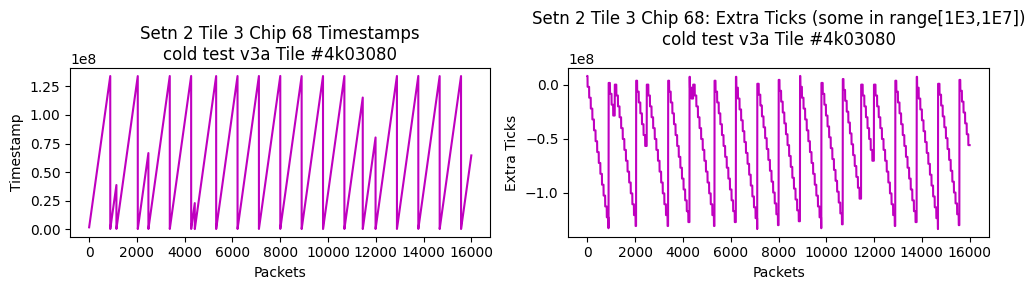

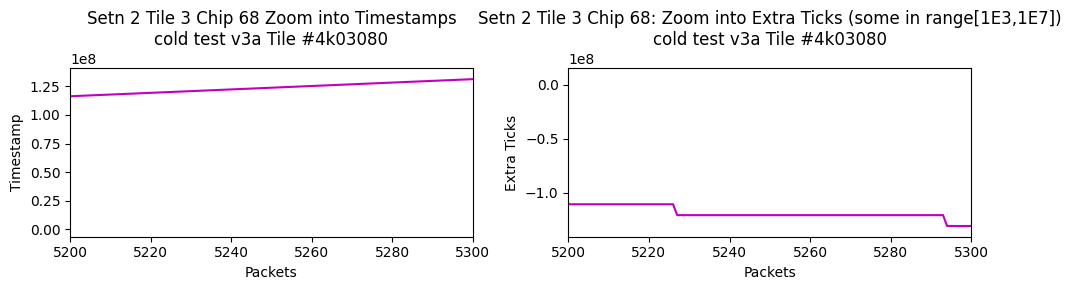

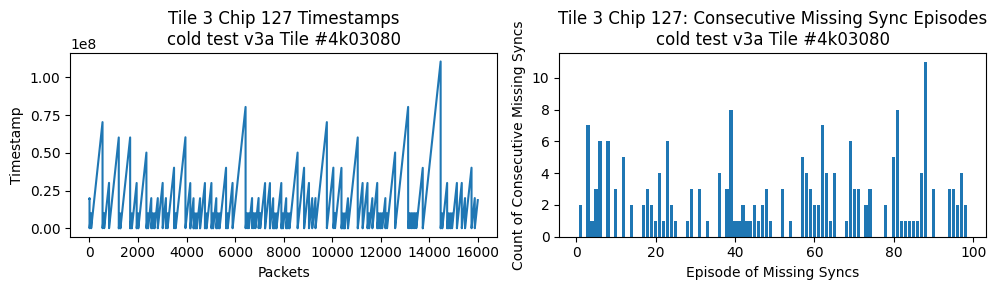

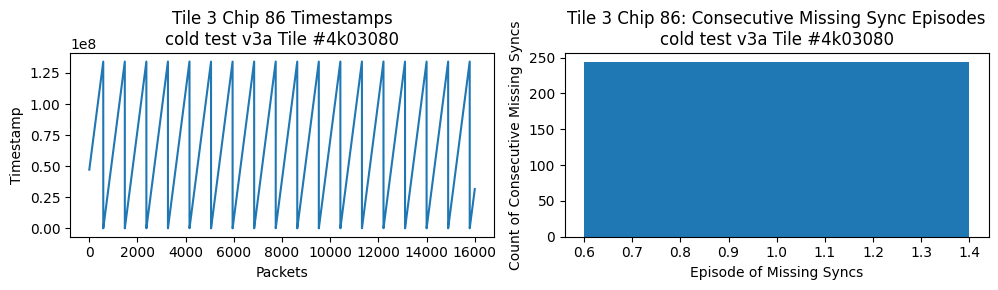

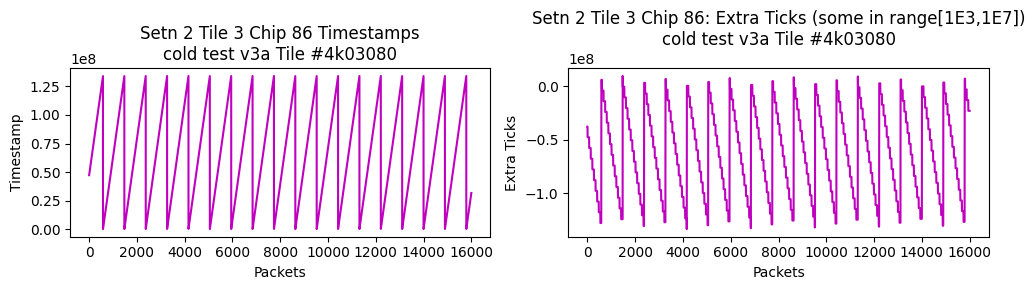

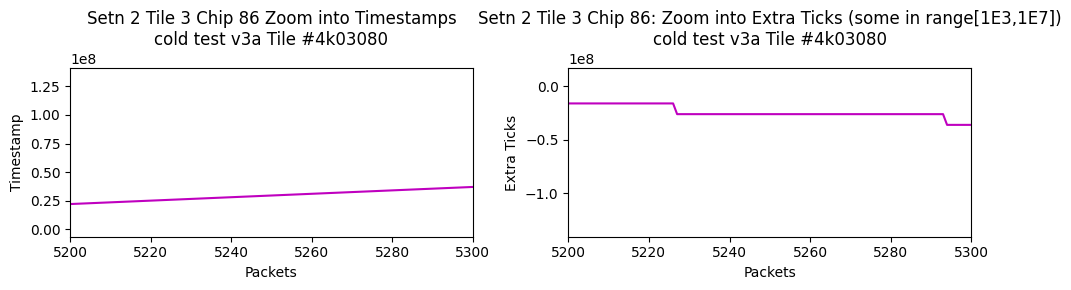

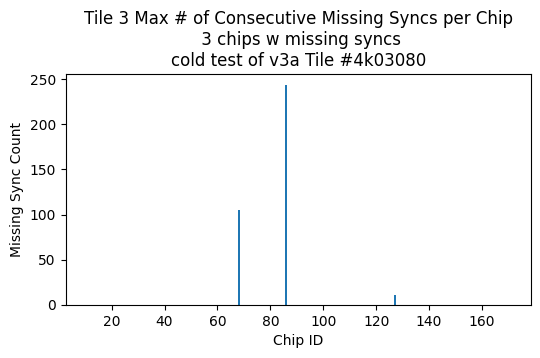

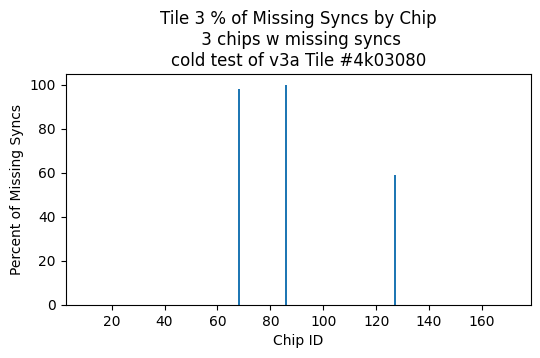

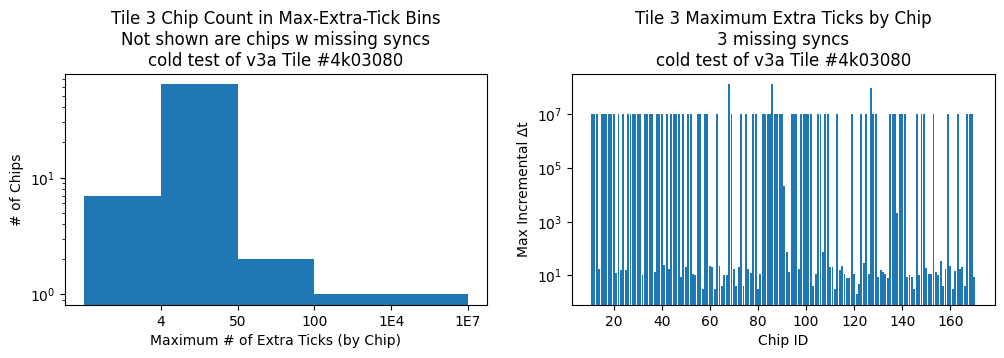

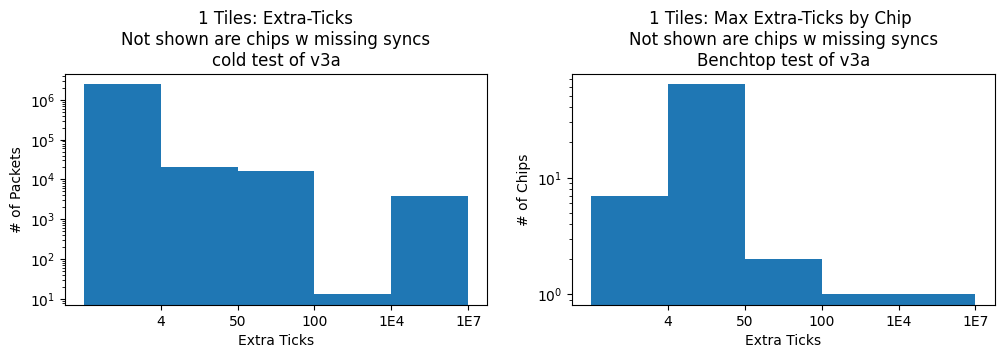

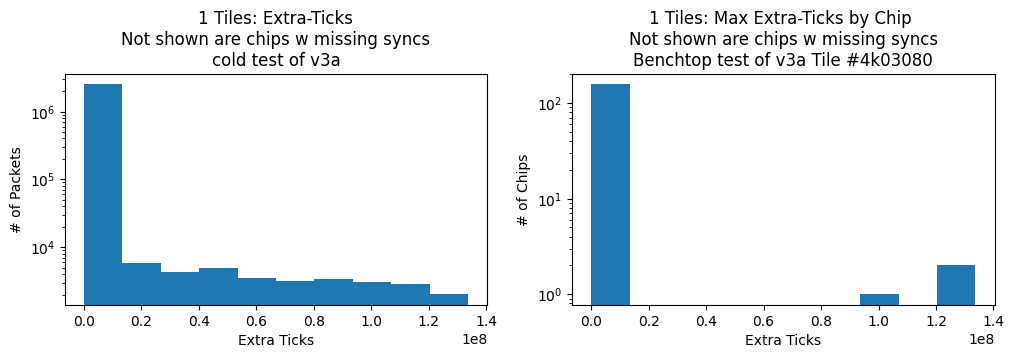

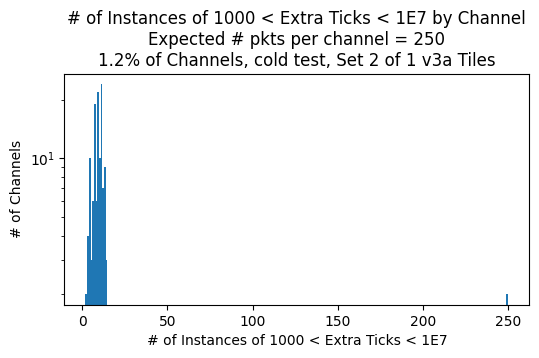

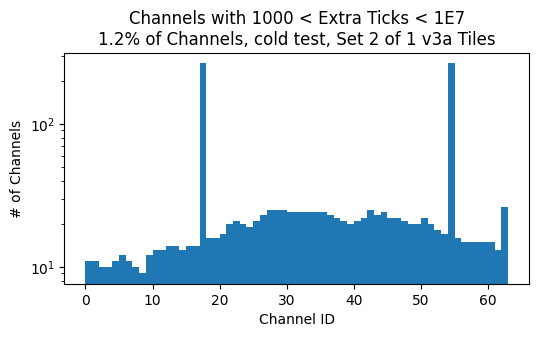

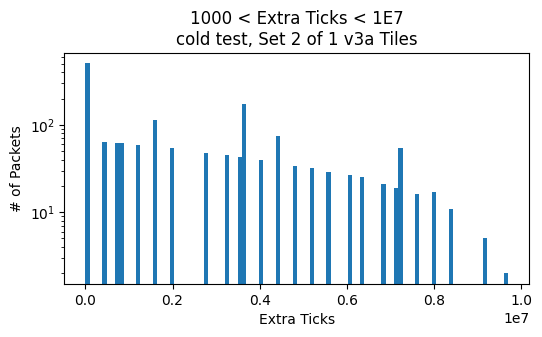

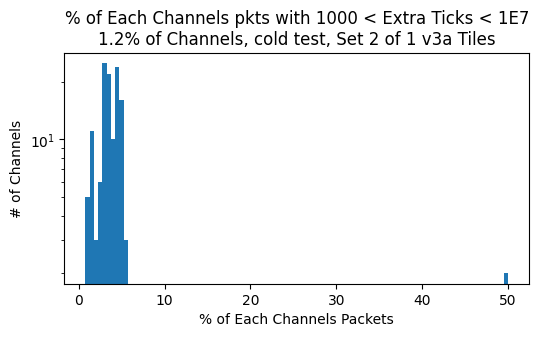

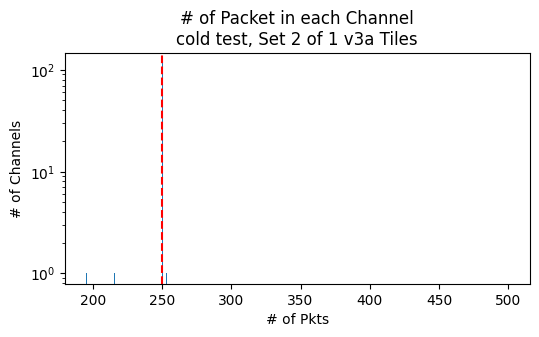

In [9]:
####################
# main
####################

print(f'Run Statistics:')

# get packets from the finename and check for missing syncs
for tile in tiles:

    # initialize
    chip_serial_number = chip_serial_number_list[tile]
    missing_sync_chip_count = 0
    missing_sync_chip_count, consecutive_missing_syncs, sync_chips, max_differences = 0, [], [], []
    max_10 = 0
    
    get_data(filename, tile, ig)

graph_all_tile(all_tile_incremental_diff, all_tile_max_differences)

graph_n_bad_by_channel(n_bad_dt, bad_channels)

#write_dt_to_file(all_tile_incremental_diff, all_tile_max_differences, bad_channels, nbad_list, percent_bad_chan)



The most common # of packets by channel = 250

127 channels (1.2% of channels tested) experienced Extra Clock Ticks > 1000

Extra tick file written to ../data/extra_ticks_cold_set_2.hdf5



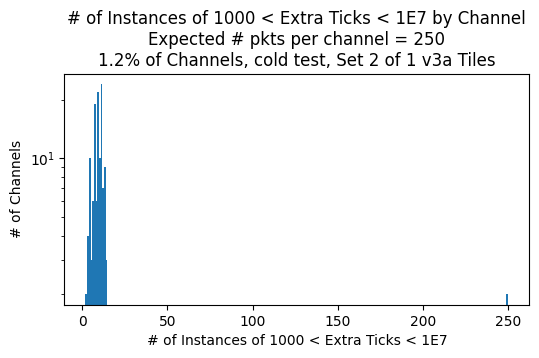

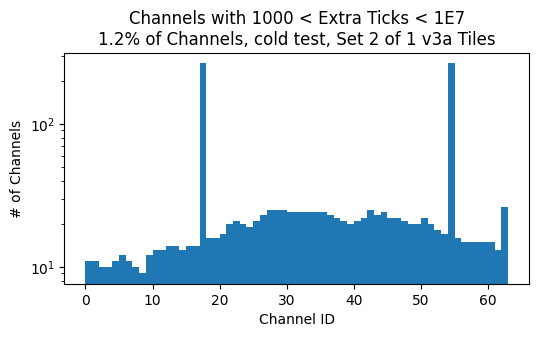

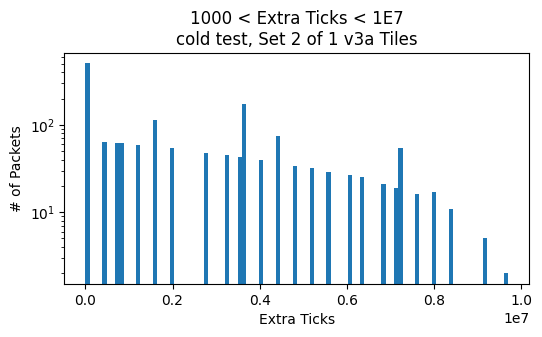

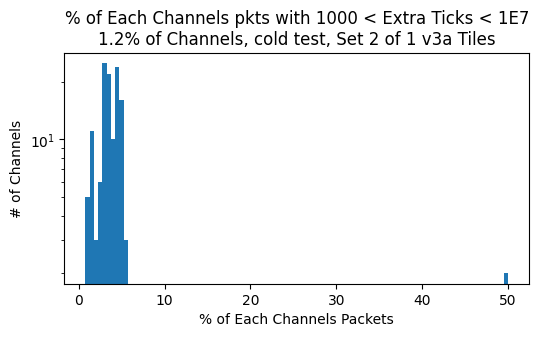

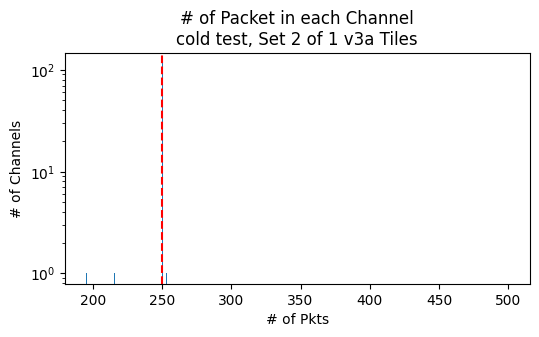

In [10]:
graph_n_bad_by_channel(n_bad_dt, bad_channels)

write_dt_to_file(all_tile_incremental_diff, all_tile_max_differences, bad_channels, nbad_list, percent_bad_chan)